
# Lab 6: Association Rule Mining with Apriori and FP-Growth
**Name:** Gregory Renteria  
**Course:** MSCS-634-M20  



## Step 1: Data Preparation
### 1.1 Import Libraries


In [32]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
from ucimlrepo import fetch_ucirepo



### 1.2 Load Dataset


In [33]:

# Fetch dataset
online_retail = fetch_ucirepo(id=352)

# Convert features to dataframe
data = online_retail.data.original

# Preview dataset
data.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


The `fetch_ucirepo()` function downloads the Online Retail dataset directly from the UCI repository. The dataset is then converted into a pandas DataFrame so it can be easily cleaned, explored, and prepared for market basket analysis in the following steps. The dataset includes several important attributes such as:
- **InvoiceNo** - Unique identifier for each transaction.
- **StockCode** - Unique product code for each item.
- **Description** - Name or description of the product purchased.
- **Quantity** - Number of units purchased in the transaction.
- **InvoiceDate** - Date and time when the transaction occurred.
- **UnitPrice** - Price of a single unit of the product.
- **CustomerID** - Unique identifier for each customer.
- **Country** - Country where the customer is located.



### 1.3 Data Cleaning


In [34]:

# Remove rows with missing descriptions
data = data.dropna(subset=['Description'])

# Remove canceled orders
data = data[~data['InvoiceNo'].astype(str).str.contains('C')]

# Keep only needed columns
data = data[['InvoiceNo','Description']]



Cleaning ensures the dataset is reliable for analysis. This step involves removing missing values, filtering canceled transactions, and keeping only the relevant columns such as transaction IDs and item names.


### 1.4 Convert Data to Transaction Format


In [35]:

transactions = data.groupby('InvoiceNo')['Description'].apply(list).tolist()

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

df = pd.DataFrame(te_array, columns=te.columns_)
df.head()


,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,wrongly coded 20713,wrongly coded 23343,wrongly coded-23343,wrongly marked,wrongly marked 23343,wrongly marked carton 22804,wrongly marked. 23343 in box,wrongly sold (22719) barcode,wrongly sold as sets,wrongly sold sets
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False



For Apriori and FP-Growth algorithms, the dataset must be converted into a **transactional format** where each row represents a transaction and each column represents whether an item was purchased. This transformatuon allows the algorithms to analyze item combinations.



### 1.5 Visualization: Most Frequent Items


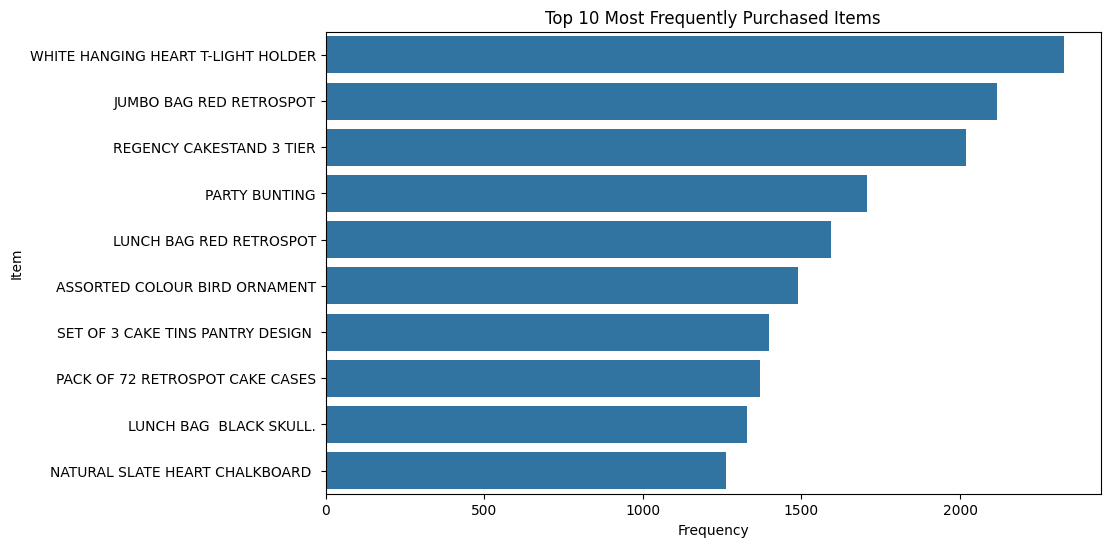

In [36]:

item_counts = data['Description'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=item_counts.values, y=item_counts.index)
plt.title("Top 10 Most Frequently Purchased Items")
plt.xlabel("Frequency")
plt.ylabel("Item")
plt.show()



A bar plot is used to display the items that appear most frequently in the database. This helps identify the most popular products and provides an initial understanding of purchasing patterns. Items like the White Hanging Heart T-Light Holder and Jumbo Bag Red Retrospot dominate the list, indicating strong, repeated customer interest.


### 1.6 Item Co-ocurrence Heatmap


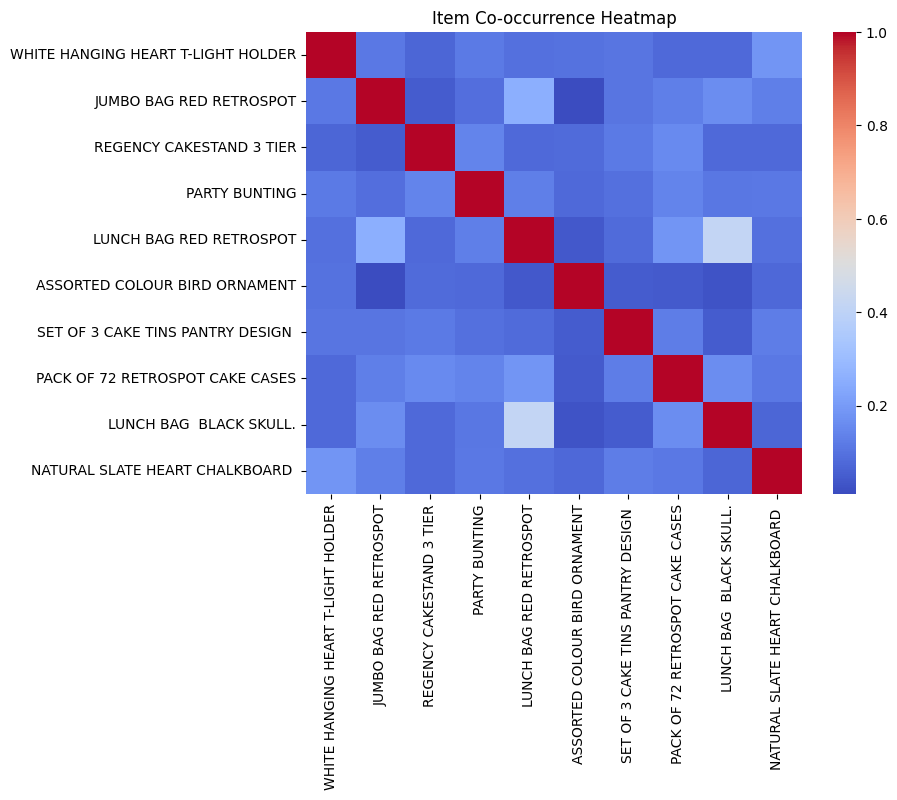

In [37]:

top_items = data['Description'].value_counts().head(10).index
subset = df[top_items]

plt.figure(figsize=(8,6))
sns.heatmap(subset.corr(), cmap="coolwarm")
plt.title("Item Co-occurrence Heatmap")
plt.show()



The heatmap illustrates how often the top items in the Online Retail dataset are purchased together, with warmer colors indicating stronger co-ocurrence between item pairs. Most relationships appear relatively weak, suggesting that while these products are individually popular, they are not consistently bought in combination.


## Step 2: Frequent Itemset Mining Using Apriori



### 2.1 Apply Apriori


In [38]:

frequent_itemsets_apriori = apriori(df, min_support=0.02, use_colnames=True)

frequent_itemsets_apriori.head()


,support,itemsets
0,0.022707,frozenset({3 STRIPEY MICE FELTCRAFT})
1,0.023484,frozenset({4 TRADITIONAL SPINNING TOPS})
2,0.046337,frozenset({6 RIBBONS RUSTIC CHARM})
3,0.021203,frozenset({60 CAKE CASES DOLLY GIRL DESIGN})
4,0.029985,frozenset({60 CAKE CASES VINTAGE CHRISTMAS})



This shows the initial output of the Apriori algorithm applied to the Online Retail dataset using a minimum support threshold of 0.02. The results list the first few frequent itemsets, each consisting of a single product that appears in the at least 2% of all transactions. The table displays each item alongside its calculated support value, illustrating which individual products meet the frequency requirement before Apriori begins generating larger item combinations.


### 2.2 Top Frequent Itemsets


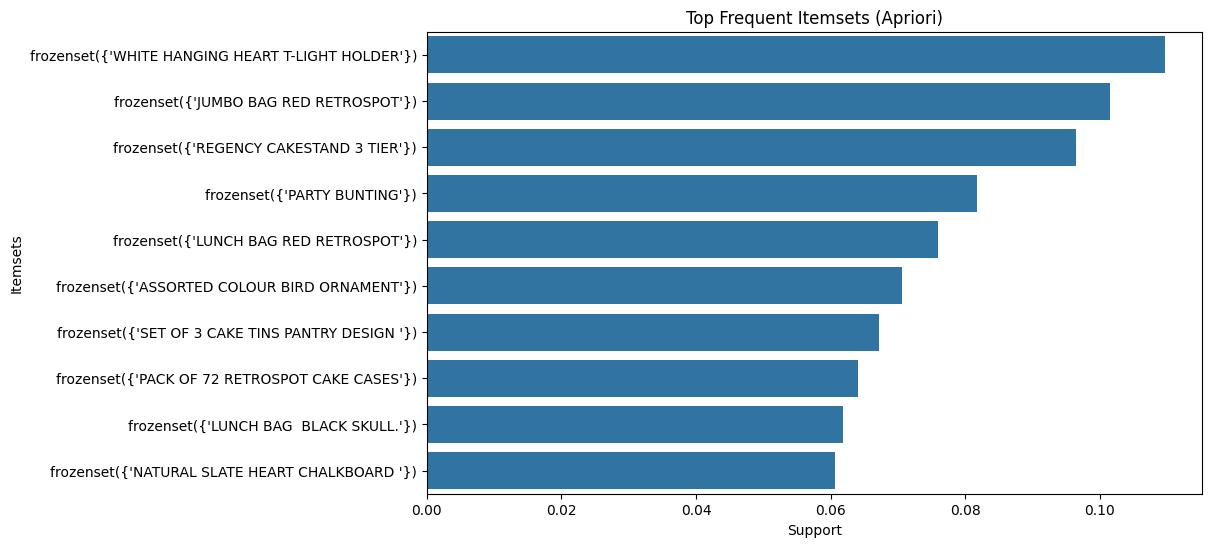

In [39]:

top_apriori = frequent_itemsets_apriori.sort_values(by='support', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='support', y=top_apriori['itemsets'].astype(str), data=top_apriori)
plt.title("Top Frequent Itemsets (Apriori)")
plt.xlabel("Support")
plt.ylabel("Itemsets")
plt.show()

The bar chart displays the most frequent itemsets identified by the Apriori algorithm, showing which individual products exceed the minimum support threshold. Each bar represents a single‑item itemset, with support values indicating how often that product appears across all transactions. The visualization highlights the same top‑selling items seen earlier in your frequency analysis, confirming that these products are strong candidates for forming larger, meaningful itemsets as Apriori progresses to 2‑item and 3‑item combinations.


## Step 3: Frequent Itemset Mining Using FP-Growth



### 3.1 Apply FP-Growth


In [40]:

frequent_itemsets_fp = fpgrowth(df, min_support=0.02, use_colnames=True)

frequent_itemsets_fp.head()


,support,itemsets
0,0.109656,frozenset({WHITE HANGING HEART T-LIGHT HOLDER})
1,0.022271,frozenset({KNITTED UNION FLAG HOT WATER BOTTLE})
2,0.020815,frozenset({RED WOOLLY HOTTIE WHITE HEART.})
3,0.023241,frozenset({HAND WARMER UNION JACK})
4,0.070597,frozenset({ASSORTED COLOUR BIRD ORNAMENT})


This shows the initial output of the FP-Growth algorithm applied with a minimum support threshold of 0.02. The table lists the first few frequent itemsets discovered, each consisting of a single product along with its support value. Compared to Apriori, FP‑Growth surfaces some of the same popular items but also highlights additional frequently purchased products, reflecting how its tree‑based structure can uncover patterns more efficiently. This output represents the starting point before FP‑Growth generates larger, more complex itemsets.


### 3.2 Visualization

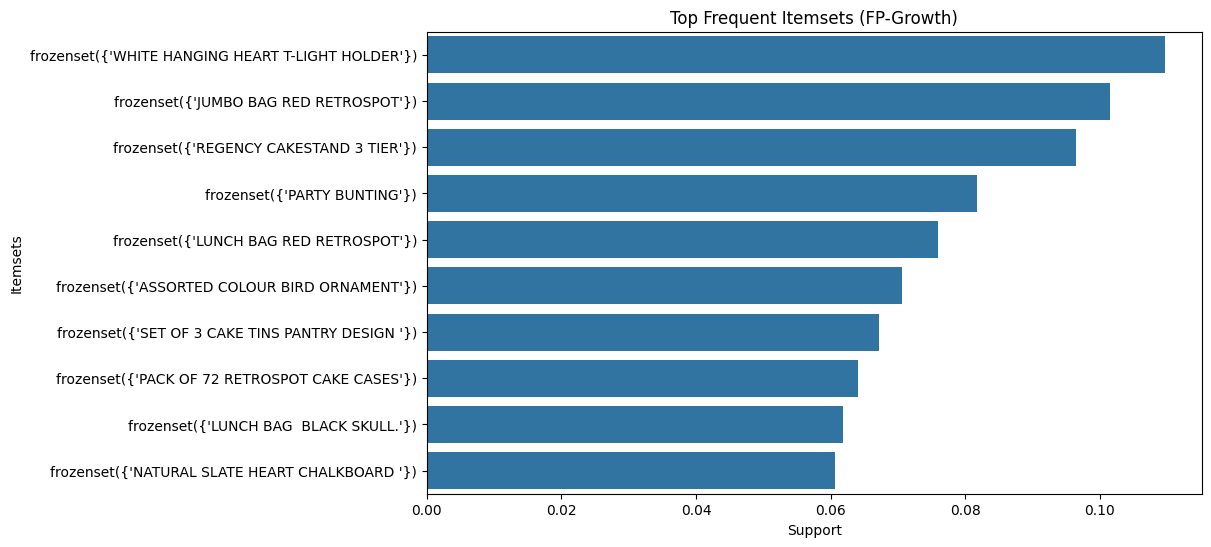

In [41]:

top_fp = frequent_itemsets_fp.sort_values(by='support', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='support', y=top_fp['itemsets'].astype(str), data=top_fp)
plt.title("Top Frequent Itemsets (FP-Growth)")
plt.xlabel("Support")
plt.ylabel("Itemsets")
plt.show()



The bar chart presents the most frequent itemsets identified by the FP‑Growth algorithm, showing which individual products appear most often across all transactions. Each bar represents a single‑item itemset along with its support value, highlighting items that consistently meet the minimum support threshold. The results closely mirror the patterns seen with Apriori, reinforcing which products are strong candidates for forming larger, meaningful item combinations during association rule mining.



## Step 4: Generating Association Rules
### 4.1 Generate Rules

In [42]:

rules = association_rules(frequent_itemsets_apriori, metric="confidence", min_threshold=0.5)

rules.head()


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({60 TEATIME FAIRY CAKE CASES}),frozenset({PACK OF 72 RETROSPOT CAKE CASES}),0.040175,0.064047,0.021980,0.547101,8.542243,1.0,0.019407,2.066585,0.919891,0.267257,0.516110,0.445142
1,frozenset({ALARM CLOCK BAKELIKE PINK}),frozenset({ALARM CLOCK BAKELIKE GREEN}),0.037991,0.047550,0.020281,0.533844,11.227070,1.0,0.018475,2.043202,0.946904,0.310781,0.510572,0.480187
2,frozenset({ALARM CLOCK BAKELIKE RED }),frozenset({ALARM CLOCK BAKELIKE GREEN}),0.050995,0.047550,0.031053,0.608944,12.806462,1.0,0.028628,2.435585,0.971453,0.460101,0.589421,0.631003
3,frozenset({ALARM CLOCK BAKELIKE GREEN}),frozenset({ALARM CLOCK BAKELIKE RED }),0.047550,0.050995,0.031053,0.653061,12.806462,1.0,0.028628,2.735368,0.967940,0.460101,0.634419,0.631003
4,frozenset({ALARM CLOCK BAKELIKE PINK}),frozenset({ALARM CLOCK BAKELIKE RED }),0.037991,0.050995,0.022804,0.600255,11.770946,1.0,0.020867,2.374029,0.951182,0.344575,0.578775,0.523724



This shows the first set of association rules generated from the Apriori frequent itemsets using a confidence threshold of 0.5. Each rule lists an antecedent, a consequent, and several evaluation metrics—including support, confidence, and lift—that help measure the strength and usefulness of the relationship. The output highlights item pairs that tend to appear together with relatively high confidence, providing insight into meaningful product associations within the Online Retail dataset.



### 4.2 Scatter Plot: Confidence vs Lift


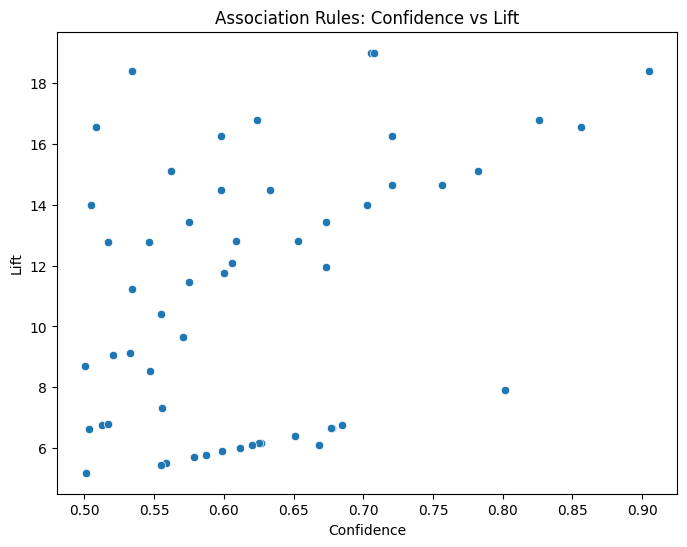

In [43]:

plt.figure(figsize=(8,6))
sns.scatterplot(x='confidence', y='lift', data=rules)
plt.title("Association Rules: Confidence vs Lift")
plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.show()



The scatter plot visualizes the relationship between confidence and lift for the association rules generated from the dataset. Each point represents a rule, showing how strongly the items are linked (lift) relative to how reliably the rule holds (confidence). The upward trend indicates that rules with higher confidence often also achieve higher lift, helping highlight the most meaningful and impactful associations uncovered during the mining process.


## Step 5: Comparative Analysis
### 5.1 Apriori vs FP-Growth



| Feature    | Apriori                      | FP-Growth              |
| ---------- | ---------------------------- | ---------------------- |
| Method     | Generates candidate itemsets | Uses FP-tree structure |
| Speed      | Slower for large datasets    | Faster                 |
| Memory Use | Higher                       | More efficient         |



This presents a side‑by‑side comparison of the Apriori and FP‑Growth algorithms, highlighting their differences in method, speed, and memory usage. Apriori relies on generating candidate itemsets, which makes it slower and more memory‑intensive on large datasets. FP‑Growth, in contrast, uses a compact FP‑tree structure that avoids candidate generation, resulting in faster performance and greater memory efficiency. This comparison helps clarify why FP‑Growth is often preferred for large‑scale association rule mining.



### 5.2 Observations
- **FP-Growth was faster** because it avoids generating large numbers of candidate itemsets.
- Both algorithms produced **similar frequent itemsets** when using the same support threshold.
- FP-Growth is generally preferred for **large transactional datasets**.


### 5.3 Challenges Encountered
**1. Data Cleaning Issues**
- Missing product descriptions.
- Cancelled transactions.
- Solution: Removed null values and cancelled orders.

**2. Dataset Transformation**
- The Apriori and FP-Growth algorithms require a **one-hot encoded transaction matrix**.
- Solution: Used `TransactionEncoder` from `mlxtend`.

**3. Performance**
- Apriori becomes slow with lower support thresholds.
- Solution: Adjusted the minimum support value.